# Figure 4 — PARSE scores reflect RNA structural quality while capturing complementary residue-level information

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

_ROOT = Path.cwd().parent.parent
_SUB = "supplemental" if Path.cwd().name == "supplemental_figures" else "main"
FIGURES = _ROOT / "figures" / _SUB

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / _SUB / name

In [2]:
def _resolution(m):
    if not isinstance(m, dict):
        return None
    return (m.get("EM Diffraction Resolution (Å)") or m.get("Refinement_resolution")
            or m.get("EM Resolution (Å)"))


def load_scores_df():
    """One row per scored structure with scores + joined validation metadata."""
    sc = json.load(open(data_file("reference/scores/scores_all_uniques.json")))["scores"]
    md = json.load(open(data_file("reference/metadata/metadata_cache.json")))
    vm = md["validation_metrics"]
    nt = md["nucleotide_counts"]
    rows = []
    for pdb, info in sc.items():
        m = vm.get(pdb) if isinstance(vm.get(pdb), dict) else {}
        rows.append({
            "pdb": pdb,
            "pairs_score": info.get("pairs_score"),
            "backbone_suiteness": info.get("backbone_suiteness"),
            "residues_score": info.get("residues_score"),
            "n_pairs": info.get("n_pairs", 0),
            "n_residues_scored": info.get("n_residues_scored", 0),
            "method": m.get("Experimental_method"),
            "resolution": _resolution(m),
            "clash": m.get("clashscore"),
            "n_nucleotides": nt.get(pdb),
        })
    return pd.DataFrame(rows)


METHOD_COLORS = {"X-ray": "tab:blue", "EM": "tab:red"}

In [3]:
df = load_scores_df()

## (A) Distribution of base-pair quality scores (X-ray vs cryo-EM)

Pair-score distribution by experimental method.

saved figures/main/figure4_A_pair_score_distribution.png


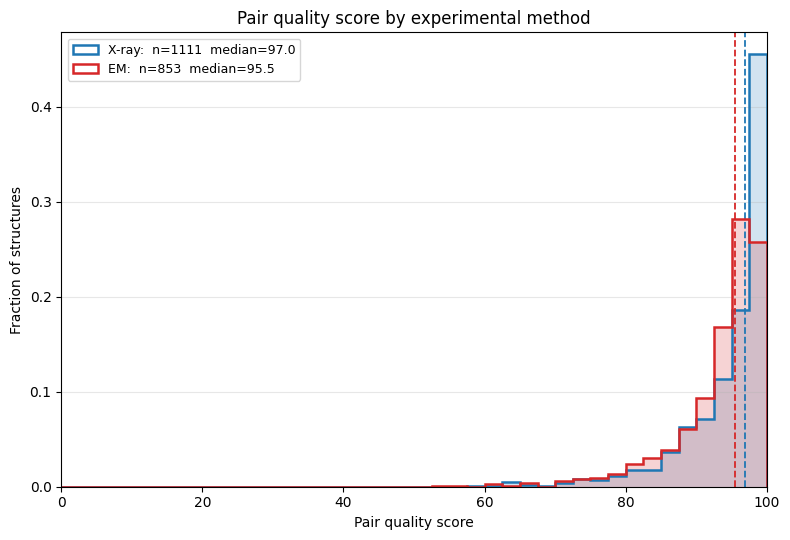

In [4]:
sub = df[df['n_pairs'] >= 5]
bins = np.linspace(0, 100, 41)
fig, ax = plt.subplots(figsize=(8, 5.5))
for method, color in [('X-ray', 'tab:blue'), ('EM', 'tab:red')]:
    vals = sub.loc[sub['method'] == method, 'pairs_score'].dropna()
    if vals.empty: continue
    w = np.ones(len(vals)) / len(vals)
    ax.hist(vals, bins=bins, weights=w, histtype='stepfilled', color=color, alpha=0.20)
    ax.hist(vals, bins=bins, weights=w, histtype='step', color=color, linewidth=1.8,
            label=f'{method}:  n={len(vals)}  median={vals.median():.1f}')
    ax.axvline(vals.median(), color=color, linestyle='--', linewidth=1.3)
ax.set_xlabel('Pair quality score'); ax.set_ylabel('Fraction of structures')
ax.set_xlim(0, 100); ax.set_title('Pair quality score by experimental method')
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3, axis='y')
fig.tight_layout(); print('saved', savefig(fig, 'figure4_A_pair_score_distribution.png')); plt.show()

## (B) Distribution of backbone quality scores (suiteness)

Backbone-suiteness distribution by experimental method.

saved figures/main/figure4_B_backbone_score_distribution.png


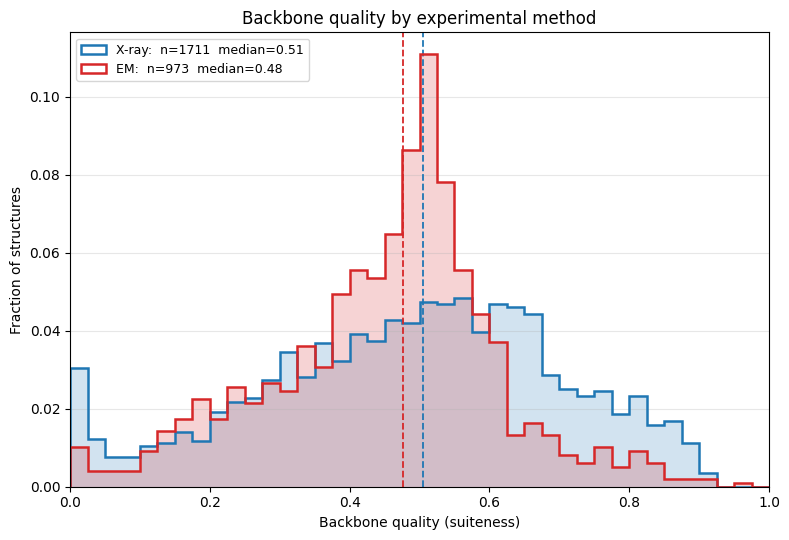

In [5]:
sub = df[df['n_residues_scored'] > 0]
bins = np.linspace(0, 1, 41)
fig, ax = plt.subplots(figsize=(8, 5.5))
for method, color in [('X-ray', 'tab:blue'), ('EM', 'tab:red')]:
    vals = sub.loc[sub['method'] == method, 'backbone_suiteness'].dropna()
    if vals.empty: continue
    w = np.ones(len(vals)) / len(vals)
    ax.hist(vals, bins=bins, weights=w, histtype='stepfilled', color=color, alpha=0.20)
    ax.hist(vals, bins=bins, weights=w, histtype='step', color=color, linewidth=1.8,
            label=f'{method}:  n={len(vals)}  median={vals.median():.2f}')
    ax.axvline(vals.median(), color=color, linestyle='--', linewidth=1.3)
ax.set_xlabel('Backbone quality (suiteness)'); ax.set_ylabel('Fraction of structures')
ax.set_xlim(0, 1); ax.set_title('Backbone quality by experimental method')
ax.legend(loc='upper left', fontsize=9); ax.grid(alpha=0.3, axis='y')
fig.tight_layout(); print('saved', savefig(fig, 'figure4_B_backbone_score_distribution.png')); plt.show()

## (C) Pair score vs experimental resolution

Pair score against experimental resolution.

saved figures/main/figure4_C_score_vs_resolution.png


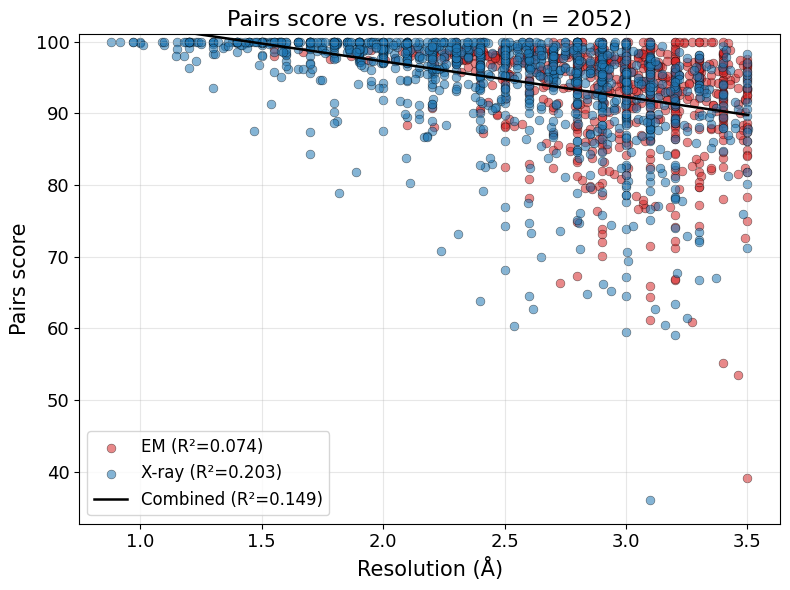

In [6]:
d = df.dropna(subset=['pairs_score', 'resolution'])
d = d[(d['resolution'] > 0) & (d['n_pairs'] >= 1)]
fig, ax = plt.subplots(figsize=(8, 6))
for method, s in d.groupby('method'):
    if method not in METHOD_COLORS: continue
    r_m, _ = pearsonr(s['resolution'], s['pairs_score'])
    ax.scatter(s['resolution'], s['pairs_score'], s=40, alpha=0.55, edgecolor='black',
               linewidth=0.4, color=METHOD_COLORS[method], label=f'{method} (R\u00b2={r_m**2:.3f})')
slope, intercept = np.polyfit(d['resolution'], d['pairs_score'], 1)
xs = np.linspace(d['resolution'].min(), d['resolution'].max(), 100)
r, _ = pearsonr(d['resolution'], d['pairs_score'])
ax.plot(xs, slope*xs + intercept, color='black', lw=1.8, label=f'Combined (R\u00b2={r**2:.3f})')
ax.set_xlabel('Resolution (\u00c5)', fontsize=15); ax.set_ylabel('Pairs score', fontsize=15)
ax.tick_params(labelsize=13); ax.grid(alpha=0.3); ax.legend(loc='lower left', fontsize=12)
ax.set_title(f'Pairs score vs. resolution (n = {len(d)})', fontsize=16); ax.set_ylim(top=101)
fig.tight_layout(); print('saved', savefig(fig, 'figure4_C_score_vs_resolution.png')); plt.show()

## (D) Pair score vs MolProbity clashscore

Pair score against clashscore.

saved figures/main/figure4_D_score_vs_clashscore.png


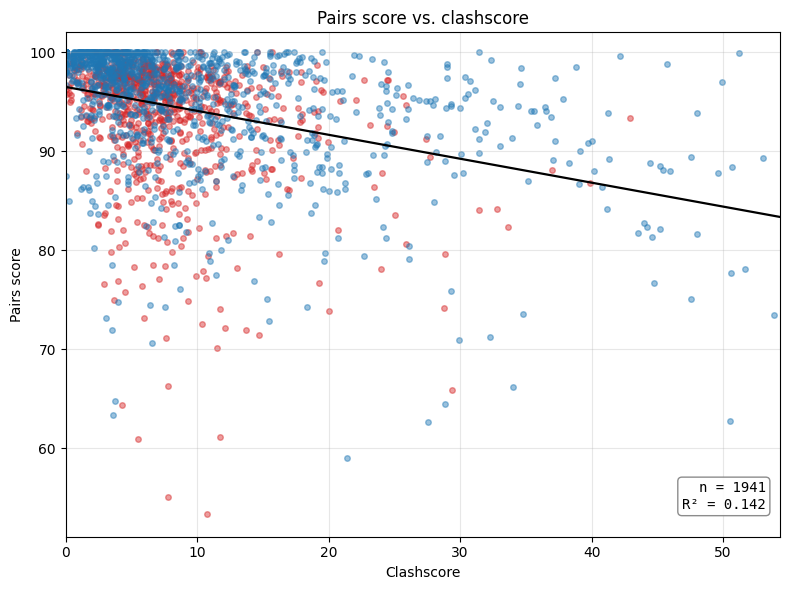

In [7]:
d = df.dropna(subset=['pairs_score', 'clash'])
d = d[d['n_pairs'] >= 5]
fig, ax = plt.subplots(figsize=(8, 6))
for method, s in d.groupby('method'):
    ax.scatter(s['clash'], s['pairs_score'], s=16, alpha=0.45,
               color=METHOD_COLORS.get(method, 'gray'))
xmax = d['clash'].quantile(0.99); mask = d['clash'] <= xmax
slope, intercept = np.polyfit(d.loc[mask, 'clash'], d.loc[mask, 'pairs_score'], 1)
xs = np.linspace(0, xmax, 100); ax.plot(xs, slope*xs + intercept, color='black', lw=1.6)
r, _ = pearsonr(d['clash'], d['pairs_score'])
ax.text(0.98, 0.05, f'n = {len(d)}\nR\u00b2 = {r**2:.3f}', transform=ax.transAxes,
        ha='right', va='bottom', family='monospace', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
ax.set_xlim(0, xmax); ax.set_ylim(top=102); ax.grid(alpha=0.3)
ax.set_xlabel('Clashscore'); ax.set_ylabel('Pairs score'); ax.set_title('Pairs score vs. clashscore')
fig.tight_layout(); print('saved', savefig(fig, 'figure4_D_score_vs_clashscore.png')); plt.show()

## (E) Pair score vs backbone suiteness

saved figures/main/figure4_E_score_vs_backbone.png


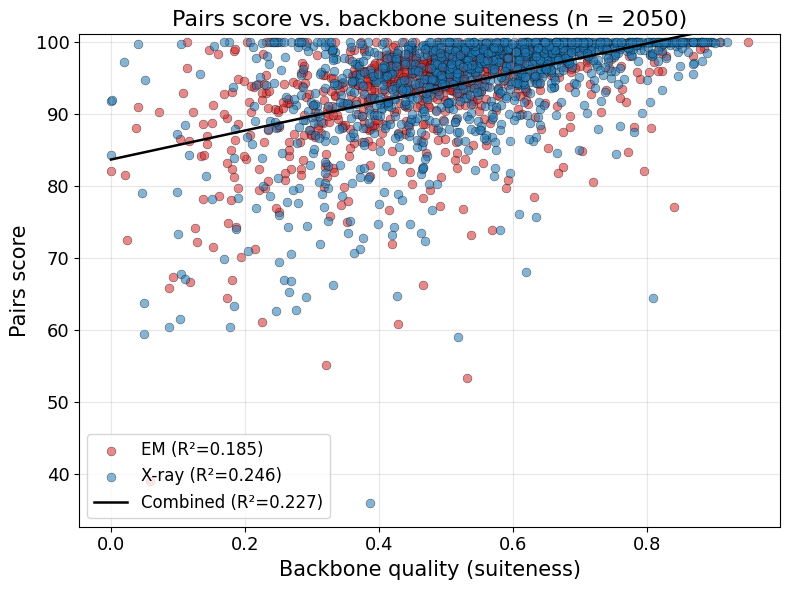

In [8]:
d = df.dropna(subset=['pairs_score', 'backbone_suiteness'])
d = d[(d['n_pairs'] >= 1) & (d['n_residues_scored'] > 0)]
fig, ax = plt.subplots(figsize=(8, 6))
for method, s in d.groupby('method'):
    if method not in METHOD_COLORS: continue
    r_m, _ = pearsonr(s['backbone_suiteness'], s['pairs_score'])
    ax.scatter(s['backbone_suiteness'], s['pairs_score'], s=40, alpha=0.55, edgecolor='black',
               linewidth=0.4, color=METHOD_COLORS[method], label=f'{method} (R\u00b2={r_m**2:.3f})')
slope, intercept = np.polyfit(d['backbone_suiteness'], d['pairs_score'], 1)
xs = np.linspace(d['backbone_suiteness'].min(), d['backbone_suiteness'].max(), 100)
r, _ = pearsonr(d['backbone_suiteness'], d['pairs_score'])
ax.plot(xs, slope*xs + intercept, color='black', lw=1.8, label=f'Combined (R\u00b2={r**2:.3f})')
ax.set_xlabel('Backbone quality (suiteness)', fontsize=15); ax.set_ylabel('Pairs score', fontsize=15)
ax.tick_params(labelsize=13); ax.grid(alpha=0.3); ax.legend(loc='lower left', fontsize=12)
ax.set_title(f'Pairs score vs. backbone suiteness (n = {len(d)})', fontsize=16); ax.set_ylim(top=101)
fig.tight_layout(); print('saved', savefig(fig, 'figure4_E_score_vs_backbone.png')); plt.show()

## (F) Pair score vs RNA length

saved figures/main/figure4_F_score_vs_nucleotides.png


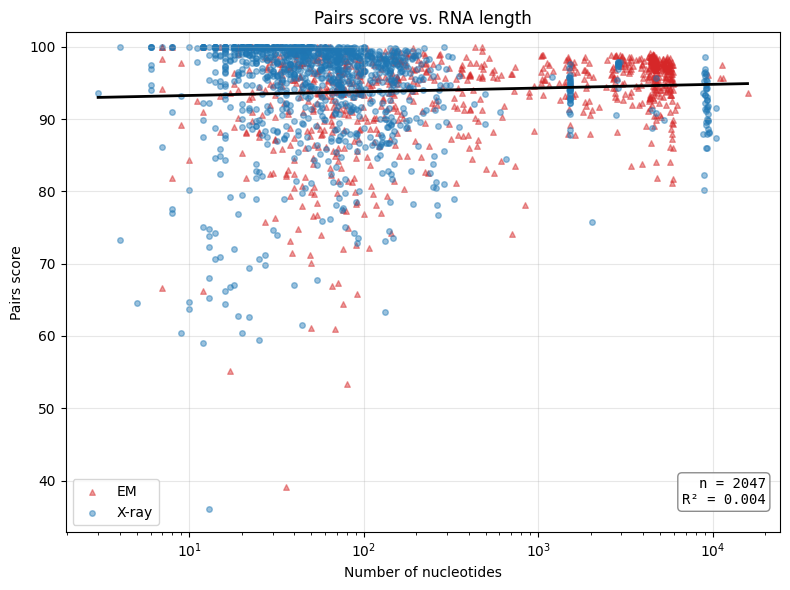

In [9]:
d = df.dropna(subset=['pairs_score', 'n_nucleotides'])
d = d[(d['n_nucleotides'] > 0) & (d['n_pairs'] >= 1)].copy()
log_n = np.log10(d['n_nucleotides'])
colors = {'X-ray': 'tab:blue', 'EM': 'tab:red'}; markers = {'X-ray': 'o', 'EM': '^'}
fig, ax = plt.subplots(figsize=(8, 6))
for method, s in d.groupby('method'):
    if method not in colors: continue
    ax.scatter(s['n_nucleotides'], s['pairs_score'], s=16, alpha=0.45,
               color=colors[method], marker=markers[method], label=method)
slope, intercept = np.polyfit(log_n, d['pairs_score'], 1)
xline = np.logspace(log_n.min(), log_n.max(), 100)
ax.plot(xline, slope*np.log10(xline) + intercept, color='black', lw=2)
r, _ = pearsonr(log_n, d['pairs_score'])
ax.text(0.98, 0.05, f'n = {len(d)}\nR\u00b2 = {r**2:.3f}', transform=ax.transAxes,
        ha='right', va='bottom', family='monospace', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
ax.set_xscale('log'); ax.set_ylim(top=102); ax.grid(alpha=0.3)
ax.set_xlabel('Number of nucleotides'); ax.set_ylabel('Pairs score')
ax.set_title('Pairs score vs. RNA length'); ax.legend(loc='lower left')
fig.tight_layout(); print('saved', savefig(fig, 'figure4_F_score_vs_nucleotides.png')); plt.show()